2413998 - Pratik Shrestha

Installing Keras

In [1]:
pip install keras tensorflow

**Task 1: Data Preparation**

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.
• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.
• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:
• Ensure that the images are resized to a consistent shape (e.g., 28x28).
• Convert labels to one-hot encoded format for multi-class classification.

Import Libraries

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# Paths to training and testing data
train_dir = "/content/drive/MyDrive/Colab Notebooks/AI AND MACHINE LEARNING/week4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/AI AND MACHINE LEARNING/week4/DevanagariHandwrittenDigitDataset/Train"

In [4]:
img_size = 28  # Resize all images to 28x28 pixels

In [5]:
# Function to load images and labels from folder
def load_data(folder):
    images = []
    labels = []

    # Map each class folder to a numeric label
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    # Iterate through each class folder and each image
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)
            img = Image.open(img_path).convert("L")   # convert to grayscale
            img = img.resize((28, 28))                # resize to 28x28
            img = np.array(img) / 255.0               # normalize to 0-1

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [6]:
# Load train and test datasets
x_train, y_train = load_data(train_dir)
x_test, y_test = load_data(test_dir)

In [7]:
# Reshape to add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [8]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [9]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (16861, 28, 28, 1)
Test shape: (16861, 28, 28, 1)


**Task 2: Build the FCN Model**

**Model Architecture**

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:– 1st hidden layer: 64 neurons– 2nd hidden layer: 128 neurons– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [10]:
# This block defines the Fully Connected Network architecture
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),  # Input layer for 28x28 grayscale images

    keras.layers.Flatten(),                  # Flatten 2D images into 1D vector

    keras.layers.Dense(64, activation='sigmoid'),   # 1st hidden layer
    keras.layers.Dense(128, activation='sigmoid'),  # 2nd hidden layer
    keras.layers.Dense(256, activation='sigmoid'),  # 3rd hidden layer

    keras.layers.Dense(10, activation='softmax')    # Output layer for 10 classes
])

model.summary()  # Display model architecture

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3: Compile the Model**

**Model Compilation**

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [11]:
# This block compiles the model with optimizer, loss, and metrics
model.compile(
    optimizer='adam',                  # Adam optimizer
    loss='categorical_crossentropy',   # Loss for multi-class classification
    metrics=['accuracy']               # Metric to monitor
)

**Task 4: Train the Model**

**Model Training**

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation
data.

split=0.2) to monitor the model’s performance on validation
• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [12]:
# This block trains the model on the training data
history = model.fit(
    x_train, y_train,
    batch_size=128,        # Number of samples per gradient update
    epochs=20,             # Train for 20 iterations over the dataset
    validation_split=0.2   # 20% of training data is used for validation
)

Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4358 - loss: 1.6783 - val_accuracy: 0.0326 - val_loss: 7.8940
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8324 - loss: 0.5672 - val_accuracy: 0.0311 - val_loss: 9.4163
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9176 - loss: 0.2961 - val_accuracy: 0.0320 - val_loss: 10.2085
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9465 - loss: 0.1981 - val_accuracy: 0.0320 - val_loss: 10.6613
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9577 - loss: 0.1489 - val_accuracy: 0.0329 - val_loss: 10.6369
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9659 - loss: 0.1209 - val_accuracy: 0.0317 - val_loss: 10.8389
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9712 - loss: 0.0973 - val_accuracy: 0.0320 - val_loss: 10.9609
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9777 - loss: 0.0806 - val_accurac

**Task 5: Evaluate the Model**

**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [13]:
# Evaluate model performance on the unseen test dataset
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

527/527 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8059 - loss: 2.5365
Test Accuracy: 0.8058834075927734
Test Loss: 2.5365443229675293


**Task 6: Save and Load the Model**

**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.

In [14]:
# Save trained model to disk
model.save("/content/drive/MyDrive/Colab Notebooks/AI AND MACHINE LEARNING/week4/devnagari_fcn_model.keras")

In [15]:
# Load it back from Drive
loaded_model = keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/AI AND MACHINE LEARNING/week4/devnagari_fcn_model.keras")

In [16]:
# Re-evaluate loaded model
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

527/527 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8059 - loss: 2.5365
Loaded Model Accuracy: 0.8058834075927734


**Task 7: Predictions**

**Making Predictions**

• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax()

In [17]:
# Make predictions on the test dataset
predictions = model.predict(x_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", true_labels[:10])

527/527 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual: [0 0 0 0 0 0 0 0 0 0]


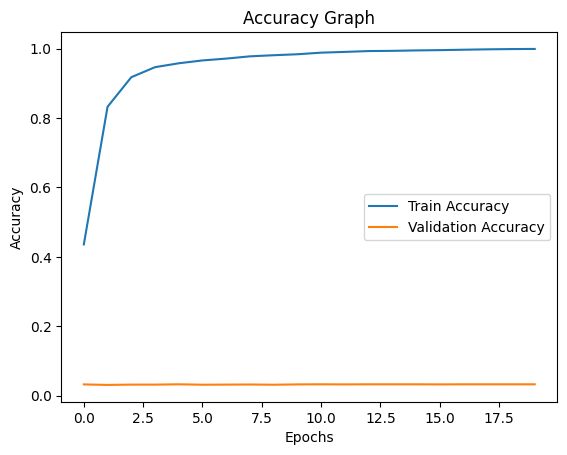

In [18]:
# VISUALIZATION
# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

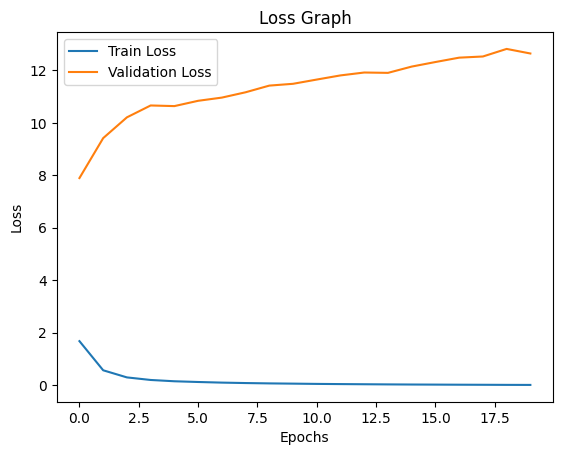

In [19]:
# Plot training and validation loss over epochs
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()